In [1]:
import json
import os

from collections import Counter
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import nltk
from nltk import word_tokenize

from textblob import TextBlob

In [2]:
IMAGE_OUTPUT_FOLDER = 'outputFiles'

In [3]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/isabel/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
try:
    with open('../dataProcessed/nurseNotesProcessed.json', 'r') as file:
        nurse_notes = json.load(file)
    print("File loaded successfully.")
    
except FileNotFoundError:
    print("Error: The file 'data.json' was not found.")

File loaded successfully.


In [5]:
# If picture folder does not exist, make it.
if not os.path.exists(f'./{IMAGE_OUTPUT_FOLDER}/'):
    os.makedirs(f'./{IMAGE_OUTPUT_FOLDER}/', exist_ok=False)  

if not os.path.exists(f'./{IMAGE_OUTPUT_FOLDER}/topWords'):
    os.makedirs(f'./{IMAGE_OUTPUT_FOLDER}/topWords', exist_ok=False)  

if not os.path.exists(f'./{IMAGE_OUTPUT_FOLDER}/wordDistributions'):
    os.makedirs(f'./{IMAGE_OUTPUT_FOLDER}/wordDistributions', exist_ok=False)  

if not os.path.exists(f'./{IMAGE_OUTPUT_FOLDER}/generalFrequencyMetrics'):
    os.makedirs(f'./{IMAGE_OUTPUT_FOLDER}/generalFrequencyMetrics', exist_ok=False)

In [6]:
analysis_dict = {
    'Resident':[], 
    'Number of Texts':[], 
    'Total Words':[],
    'Unique Words / Vocab Size':[],
    'Average Text Length':[],
    'Average Text Word Count':[],
    'Shortest Text Word Count':[],
    'Longest Text Word Count':[],
    'Most Common n-grams':[],
    'Most Common Word':[],
    'Sentiment':[],
    'Subjectivity':[]
    } 

In [7]:
def text_statistics(texts, key, analysis_dict):
    lengths = [len(t) for t in texts]
    all_tokens = [word_tokenize(t) for t in texts]
    word_counts = [len(tok) for tok in all_tokens]

    all_words = [w for tok in all_tokens for w in tok]
    vocab = set(all_words)

    all_words = [w for t in texts for w in word_tokenize(t)]
    counter = Counter(all_words)

    ngrams = []
    for tokens in all_tokens:
        ngrams += zip(*[tokens[i:] for i in range(2)])

    counter_ngrams = Counter(ngrams)

    polarities = []
    subjectivities = []
    for i, text in enumerate(texts[:5]):
        temp_text_blob = TextBlob(text)
        polarities.append(temp_text_blob.sentiment.polarity)
        subjectivities.append(temp_text_blob.sentiment.subjectivity)

    analysis_dict['Resident'].append(key)
    analysis_dict['Number of Texts'].append(len(texts))
    analysis_dict['Total Words'].append(len(all_words))
    analysis_dict['Unique Words / Vocab Size'].append(len(vocab))
    analysis_dict['Average Text Length'].append(sum(lengths)/len(lengths))
    analysis_dict['Average Text Word Count'].append(sum(word_counts)/len(word_counts))
    analysis_dict['Shortest Text Word Count'].append(min(word_counts))
    analysis_dict['Longest Text Word Count'].append(max(word_counts))
    analysis_dict['Most Common n-grams'].append(counter_ngrams.most_common(10))
    analysis_dict['Most Common Word'].append(counter.most_common(10))
    analysis_dict['Sentiment'].append(np.array(polarities).mean())
    analysis_dict['Subjectivity'].append(np.array(subjectivities).mean())
    
    return analysis_dict


In [8]:
def plot_word_distribution(texts, file_name = ''):
    word_counts = [len(word_tokenize(t)) for t in texts]

    plt.figure()
    plt.hist(word_counts, bins=20)
    plt.xlabel("Words per Text")
    plt.ylabel("Frequency")
    plt.tight_layout()
    if file_name != '':
        plt.savefig(f"./{IMAGE_OUTPUT_FOLDER}/{file_name}WordDistribution.png", bbox_inches='tight', dpi=300)
    plt.show()

In [9]:
def plot_top_words(texts, n, file_name = ''):
    all_words = [w for t in texts for w in word_tokenize(t)]
    counter = Counter(all_words)
    common = counter.most_common(n)

    words = [w for w, _ in common]
    freqs = [f for _, f in common]

    plt.figure()
    plt.bar(words, freqs)
    plt.xticks(rotation=45)
    plt.ylabel("Frequency")
    plt.tight_layout()
    if file_name != '':
        plt.savefig(f"./{IMAGE_OUTPUT_FOLDER}/{file_name}TopWords.png", bbox_inches='tight', dpi=300)
    plt.show()

-----------P1-----------


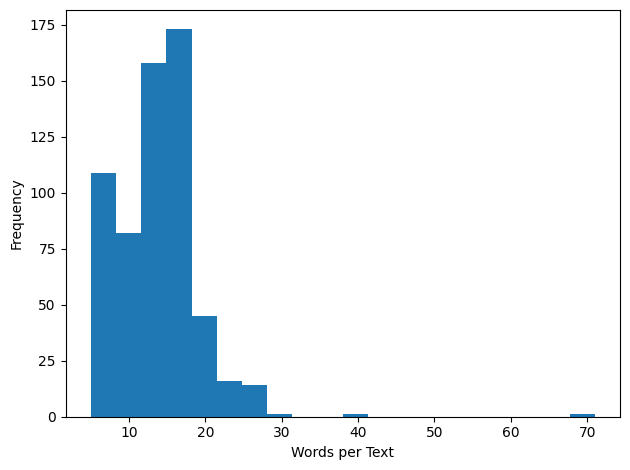

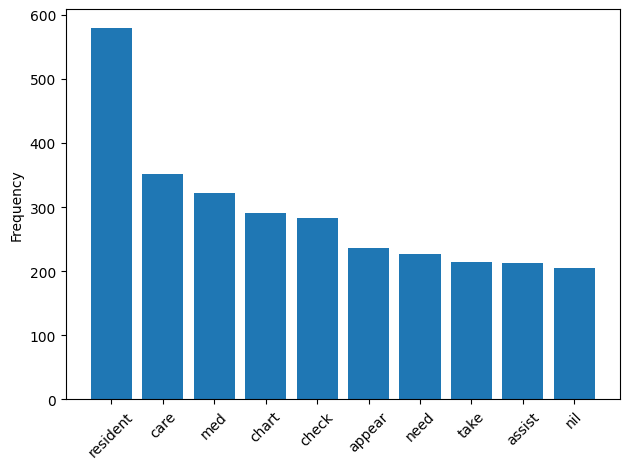

-----------P10-----------


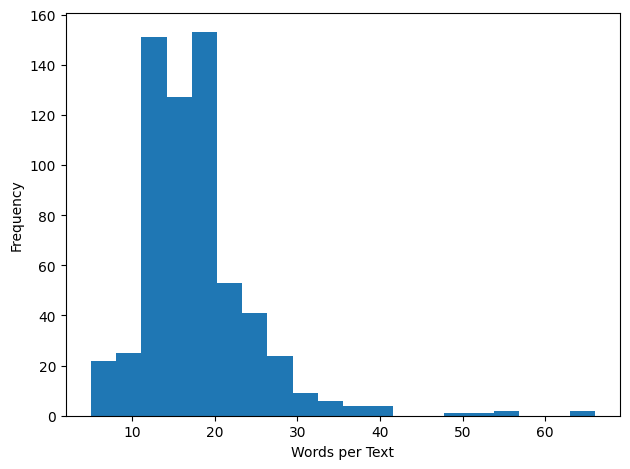

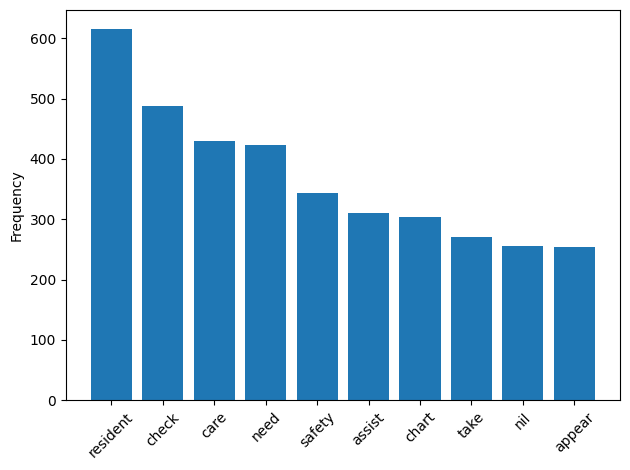

-----------P11-----------


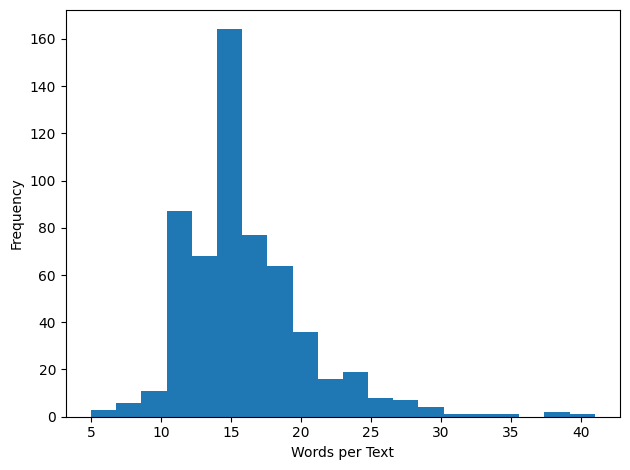

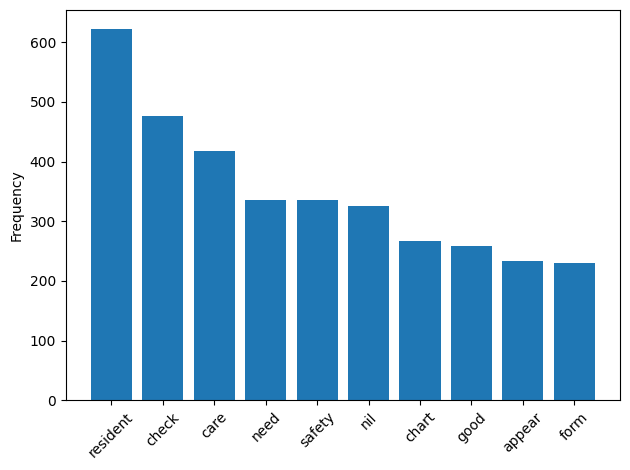

-----------P12-----------


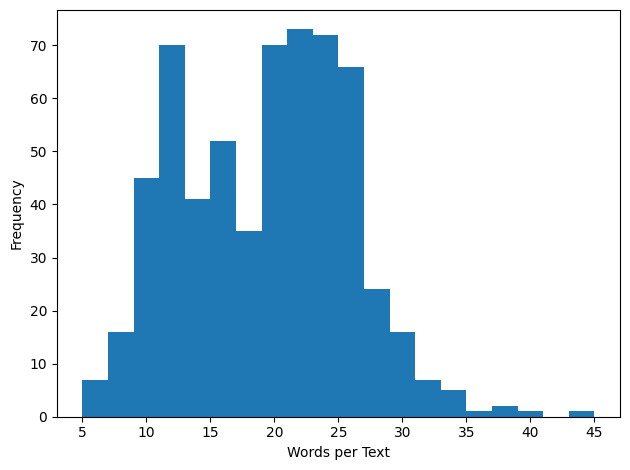

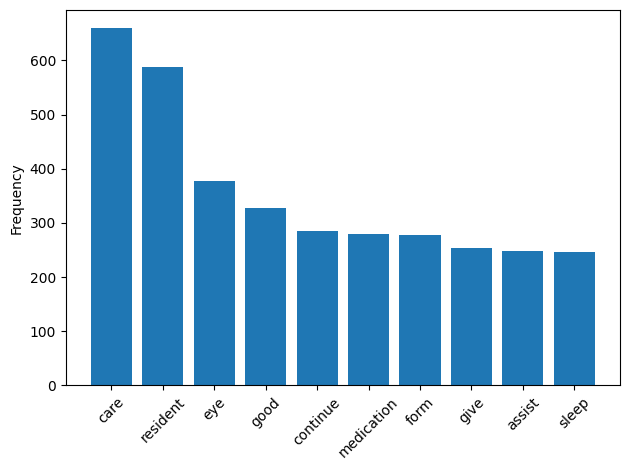

-----------P13-----------


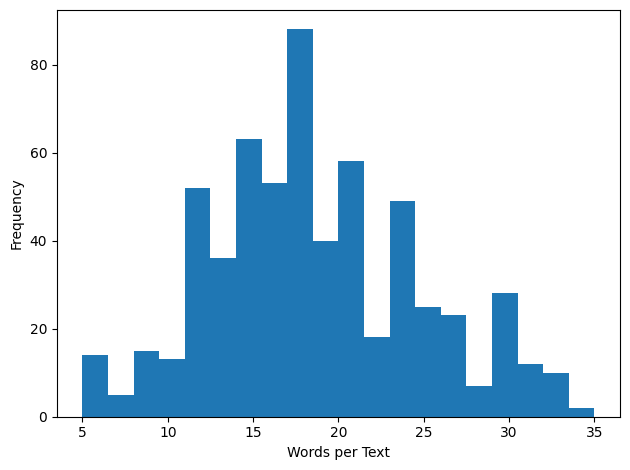

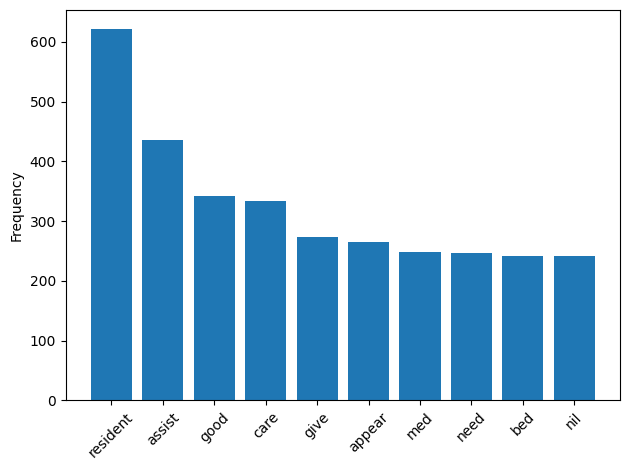

-----------P14-----------


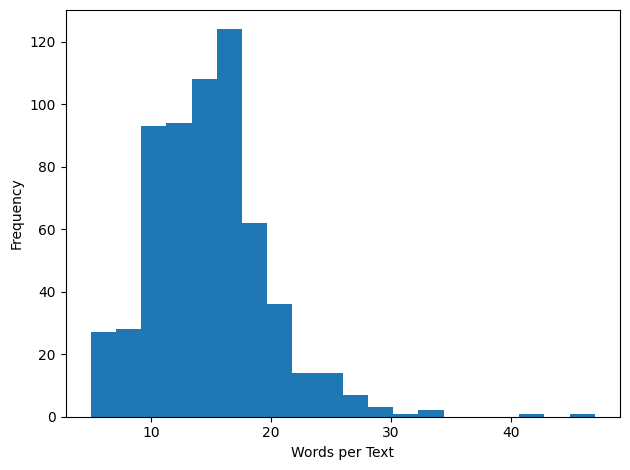

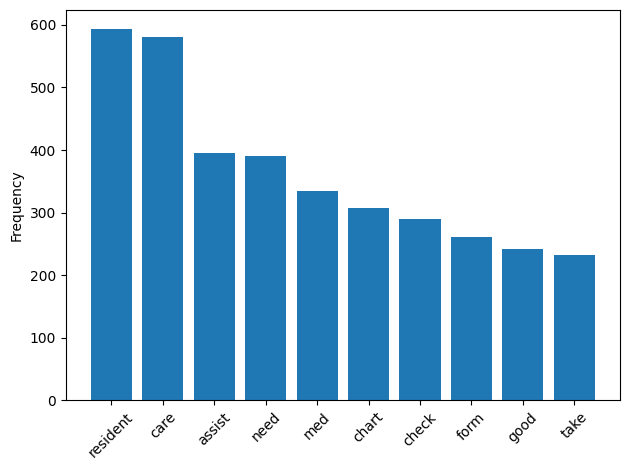

-----------P15-----------


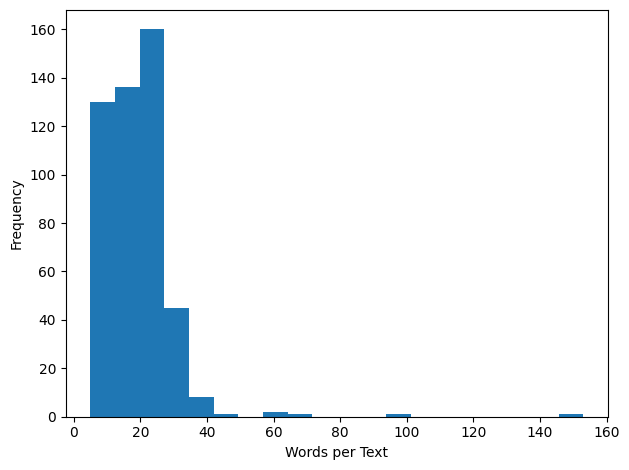

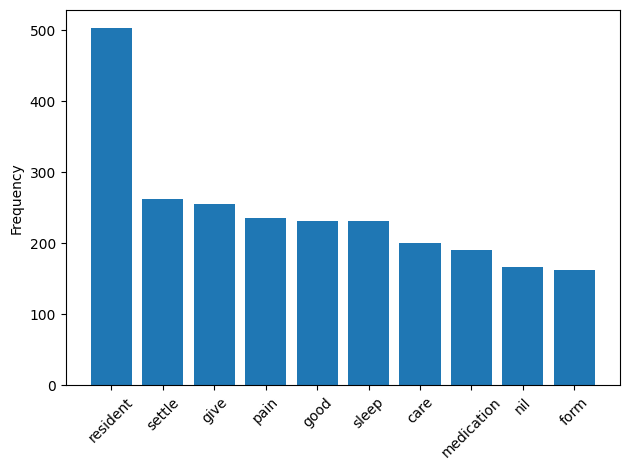

-----------P16-----------


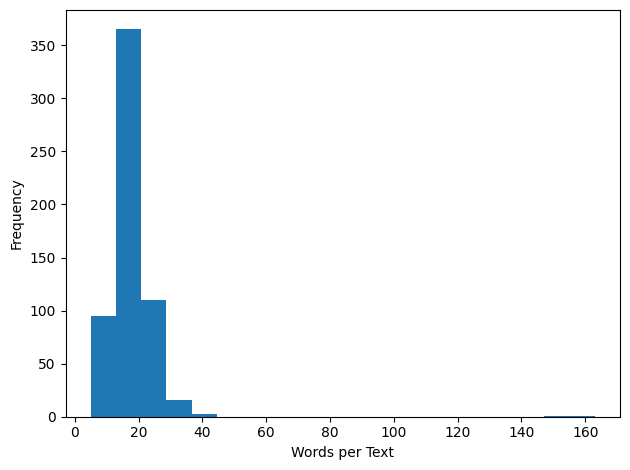

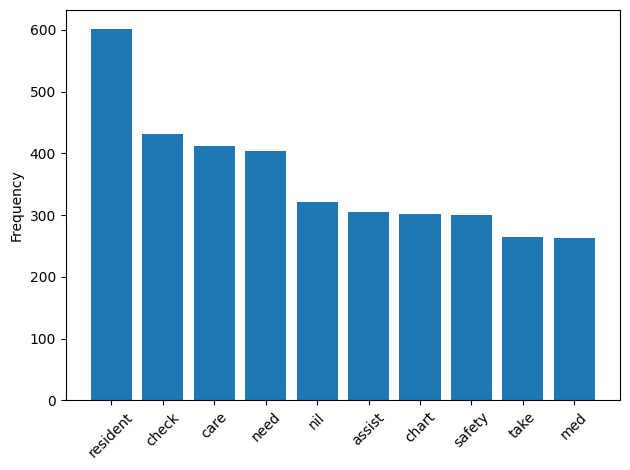

-----------P17-----------


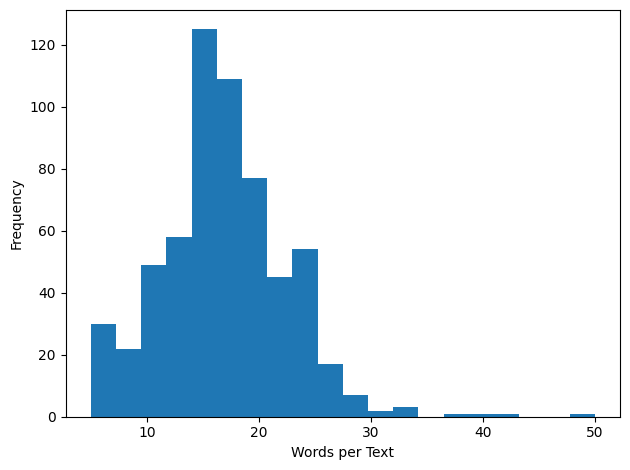

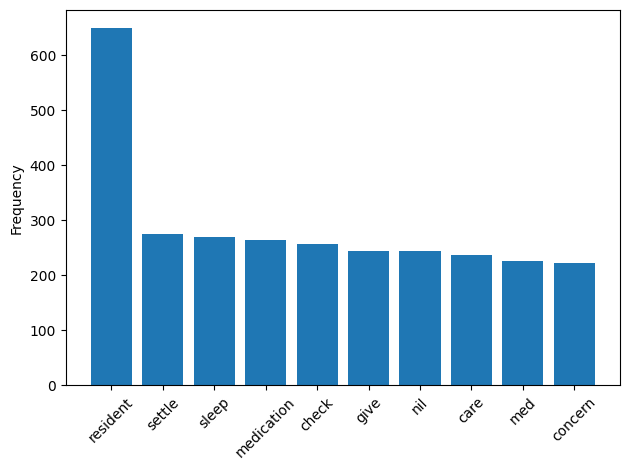

-----------P18-----------


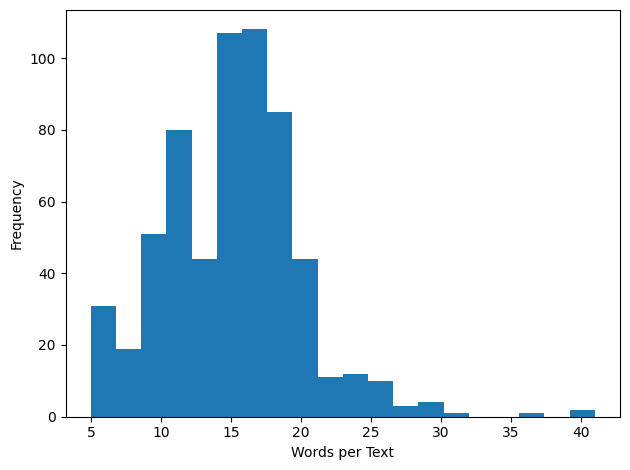

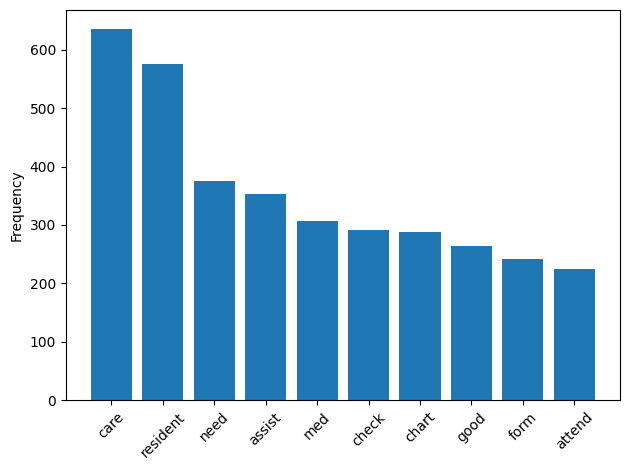

-----------P19-----------


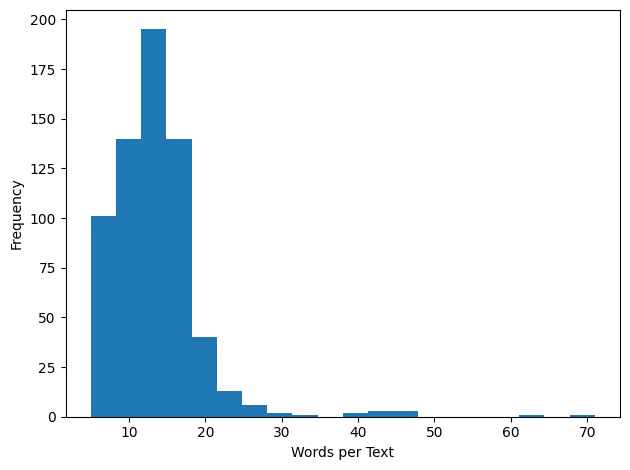

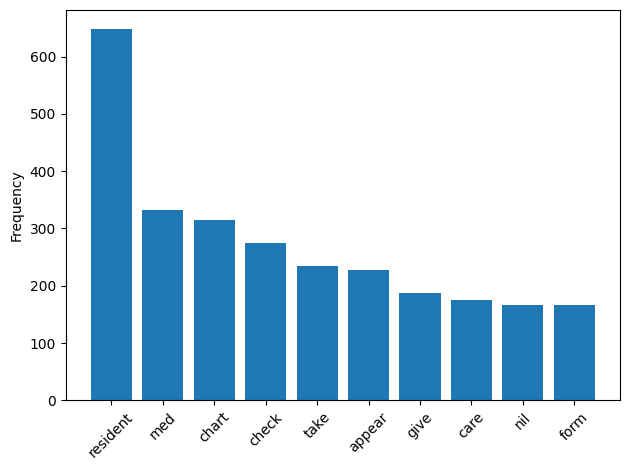

-----------P2-----------


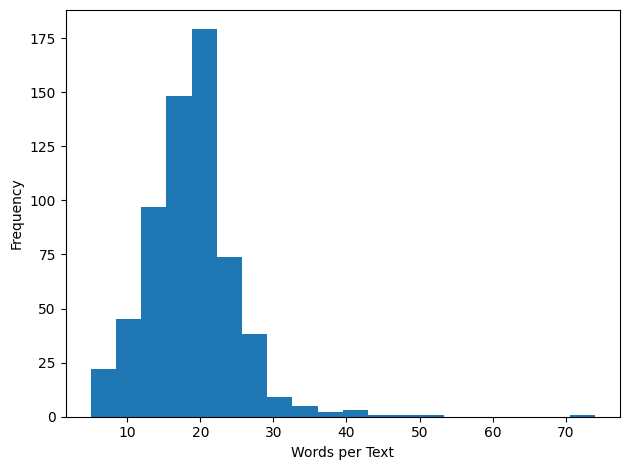

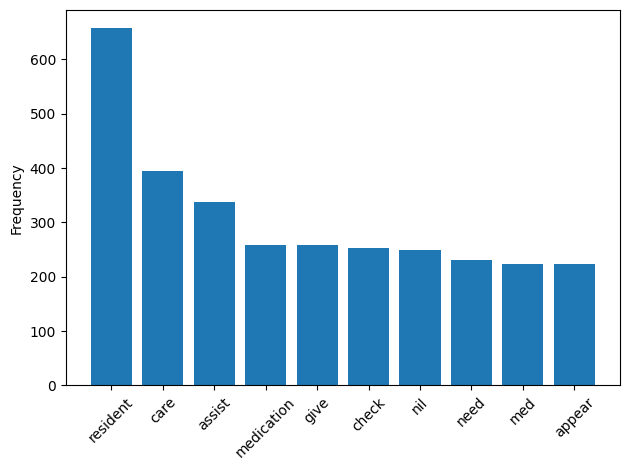

-----------P20-----------


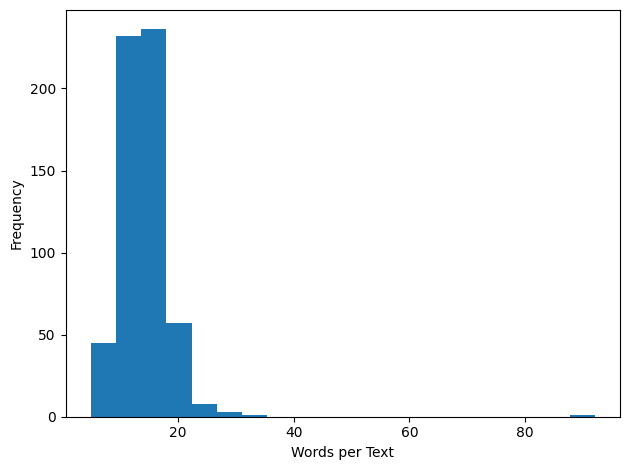

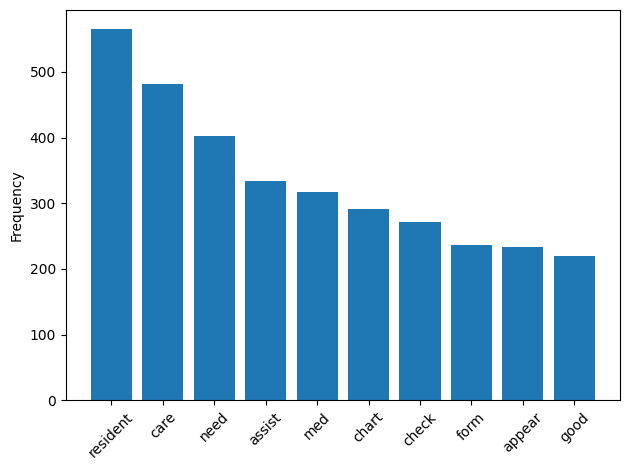

-----------P3-----------


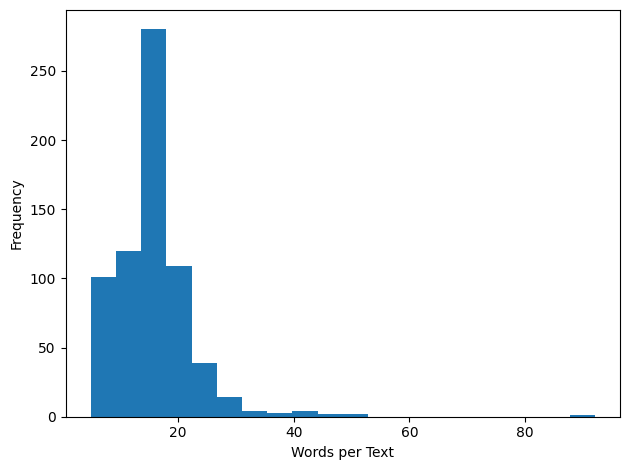

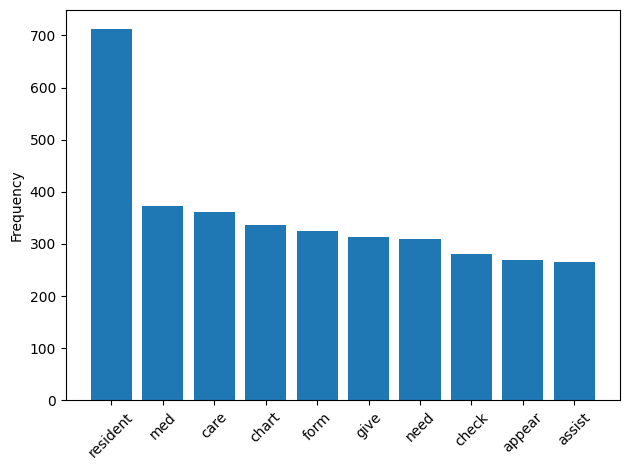

-----------P4-----------


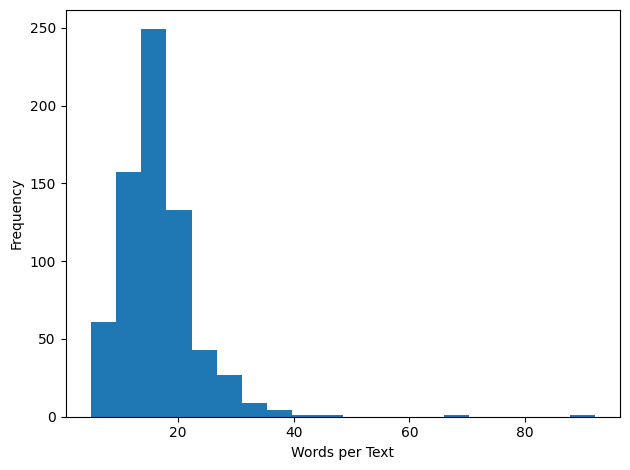

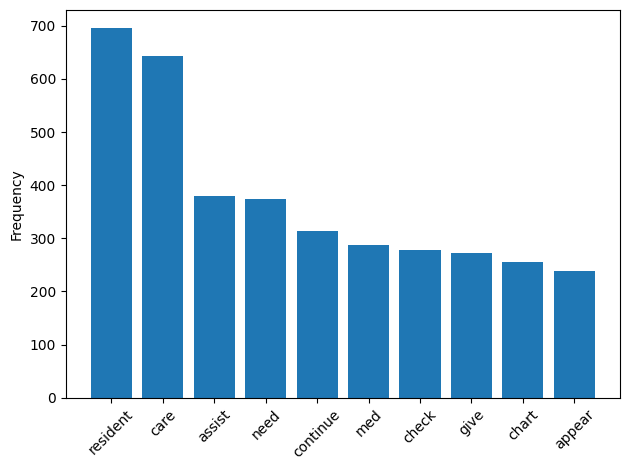

-----------P5-----------


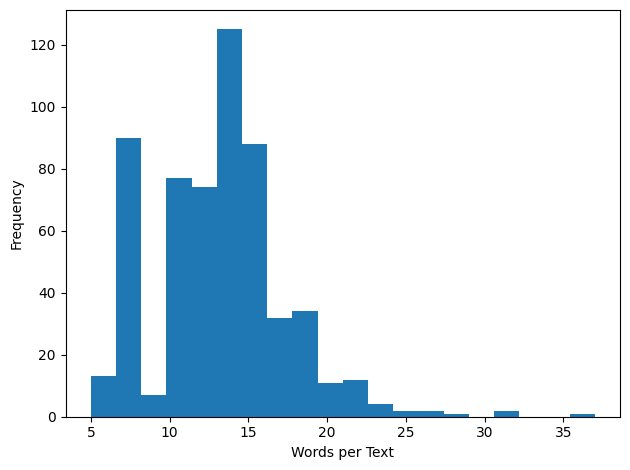

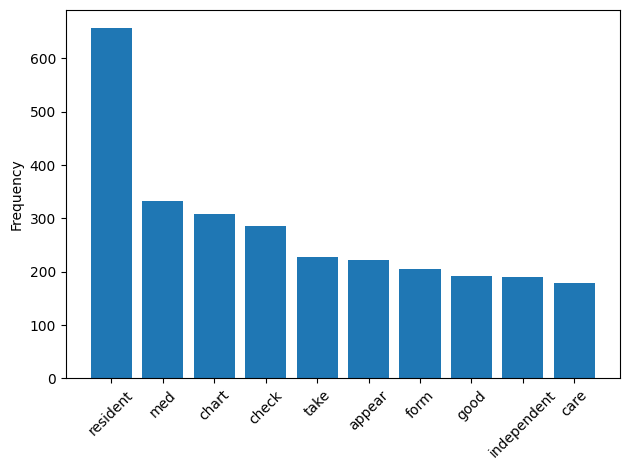

-----------P6-----------


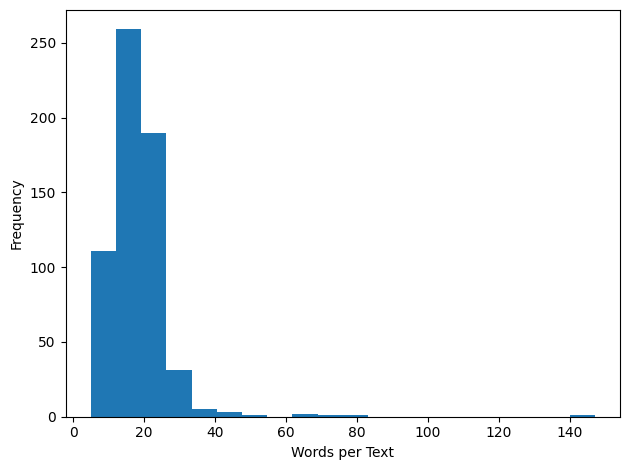

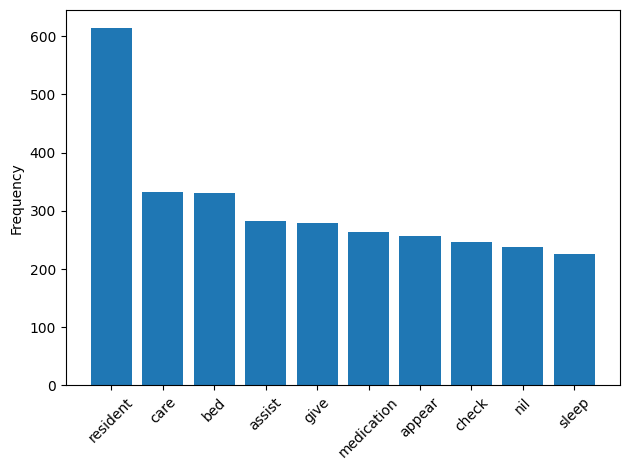

-----------P7-----------


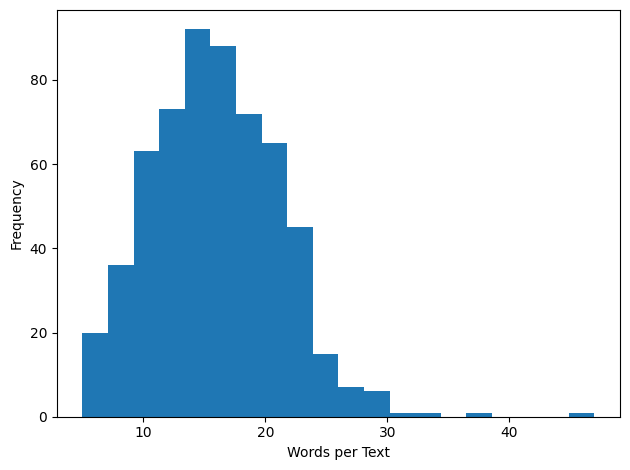

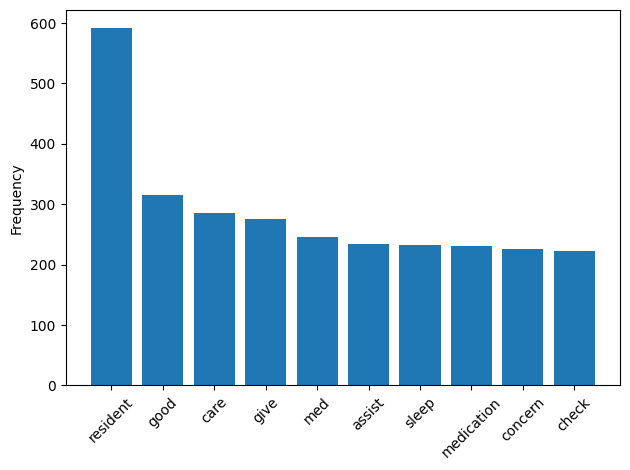

-----------P8-----------


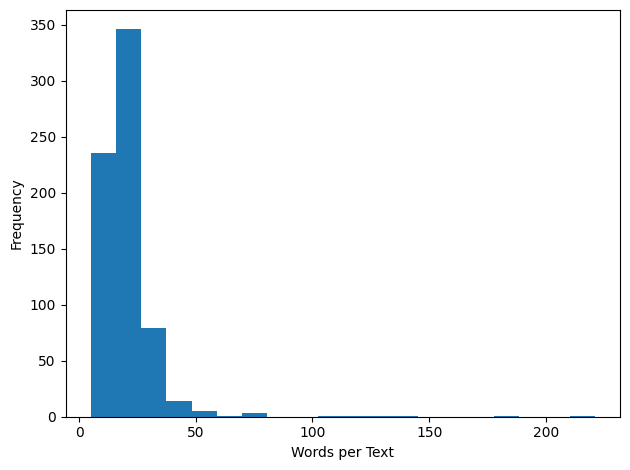

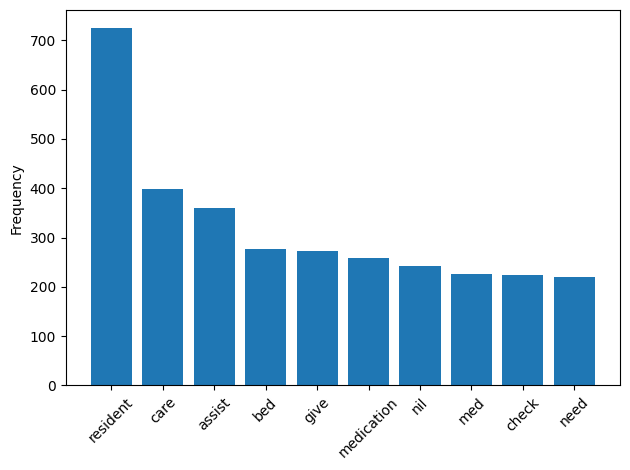

-----------P9-----------


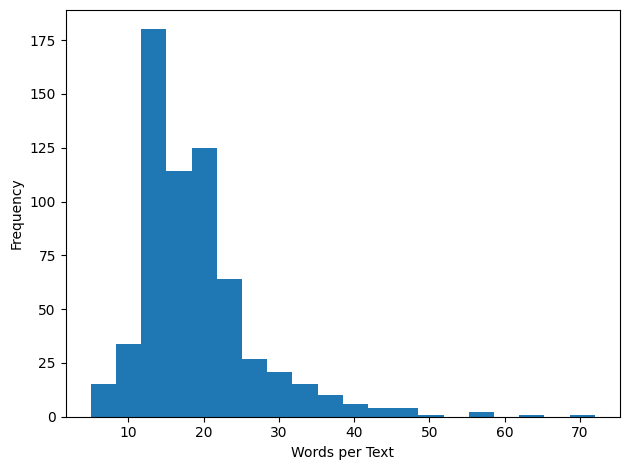

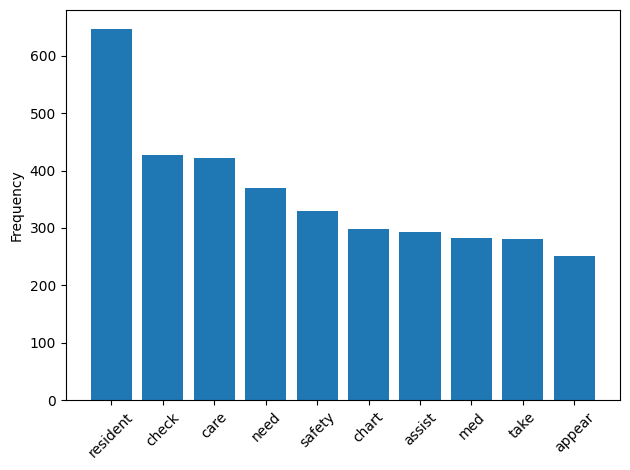

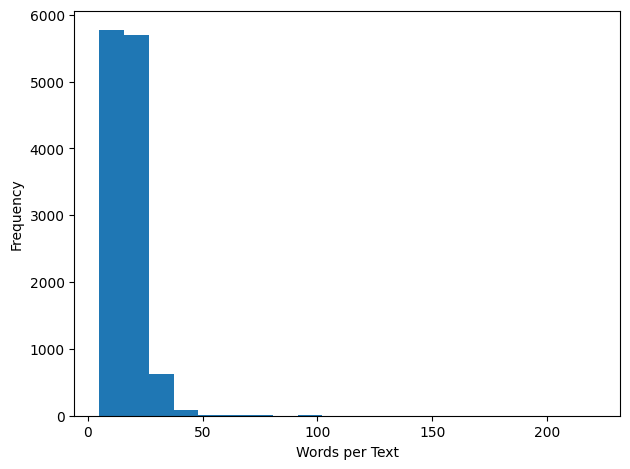

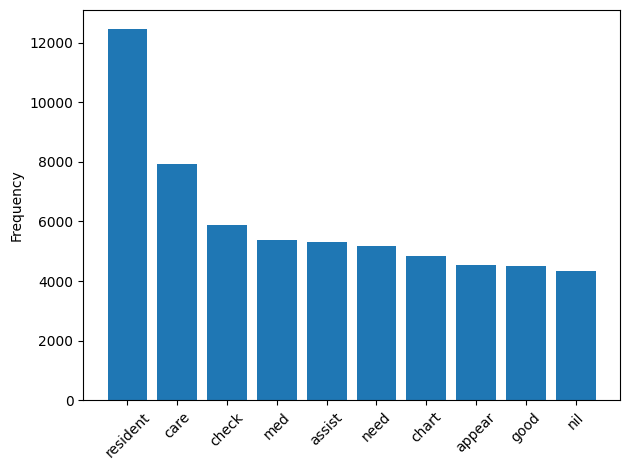

In [10]:
all_texts = []
for key in nurse_notes.keys():
    print(f"-----------{key}-----------")
    analysis_dict = text_statistics(nurse_notes[key], key, analysis_dict)
    plot_word_distribution(nurse_notes[key], file_name=f"wordDistributions/{key}")
    plot_top_words(nurse_notes[key], 10, file_name=f"topWords/{key}")
    all_texts.extend(nurse_notes[key])

analysis_dict = text_statistics(all_texts, "All Notes", analysis_dict)
plot_word_distribution(all_texts, file_name="wordDistributions/allNotes")
plot_top_words(all_texts, 10, file_name="topWords/allNotes")

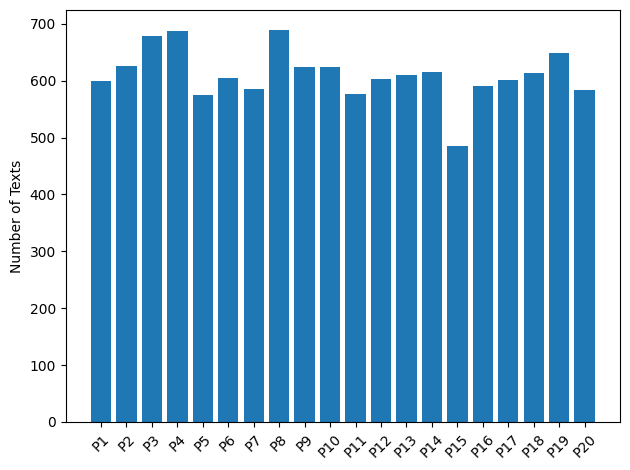

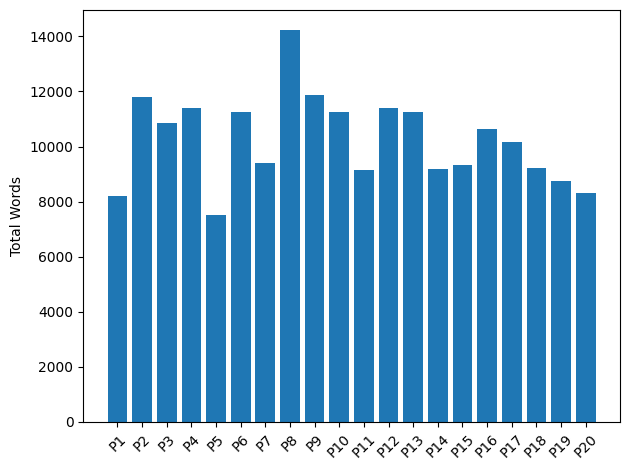

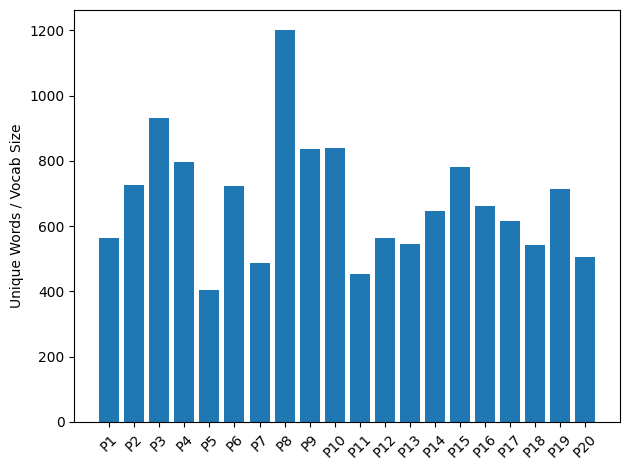

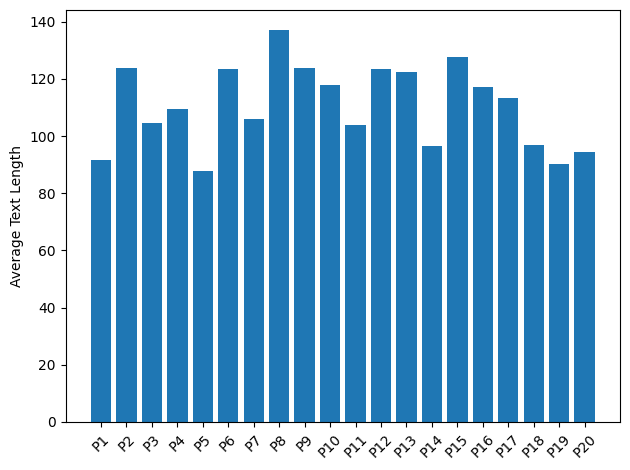

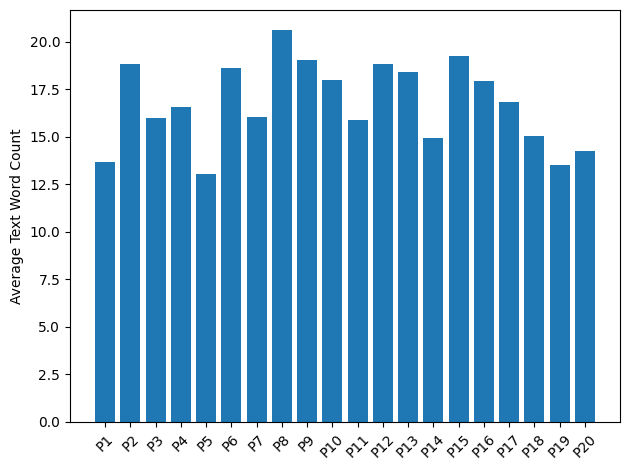

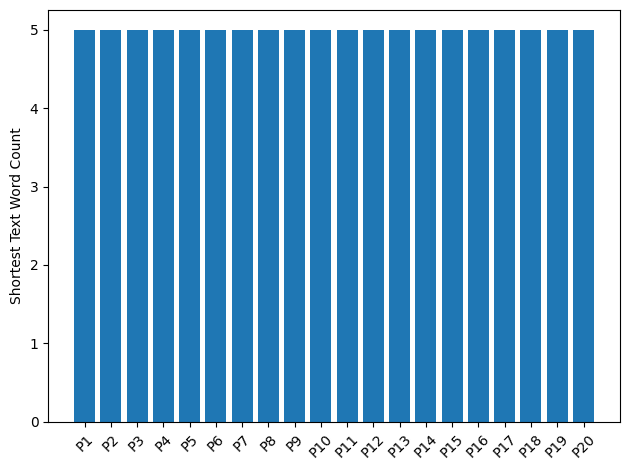

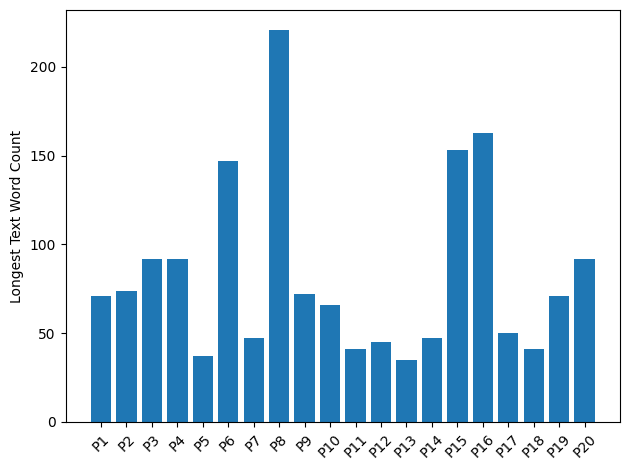

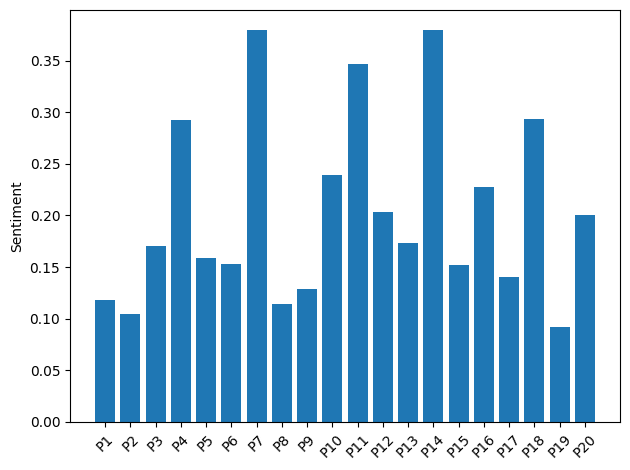

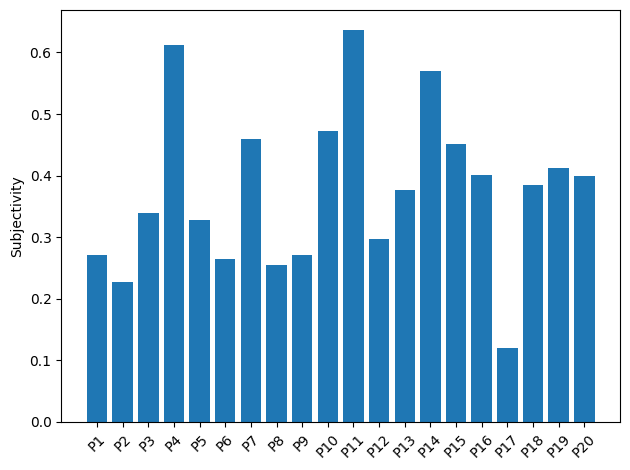

In [11]:
analysis_df = pd.DataFrame(analysis_dict)
analysis_df.to_csv(f"./{IMAGE_OUTPUT_FOLDER}/analysisMetrics.csv")
analysis_df.to_excel(f"./{IMAGE_OUTPUT_FOLDER}/analysisMetrics.xlsx")
all_notes_row = analysis_df[analysis_df['Resident'] == 'All Notes']
analysis_df= analysis_df[analysis_df['Resident'] != 'All Notes']
analysis_df = analysis_df.sort_values(
    by="Resident",
    key=lambda col: col.str.extract(r"(\d+)")[0].astype(int)
)
residents = analysis_df['Resident']
analysis_df = analysis_df.drop(columns=['Resident', 'Most Common n-grams', 'Most Common Word'])

for column in analysis_df.columns:
    plt.bar(residents, analysis_df[column])
    plt.xticks(rotation=45)
    plt.ylabel(column)
    plt.tight_layout()
    file_name = column.replace(' ', '').replace('/', '')
    plt.savefig(f"./{IMAGE_OUTPUT_FOLDER}/generalFrequencyMetrics/{file_name[:1].lower() + file_name[1:]}.png", bbox_inches='tight', dpi=300)
    plt.show()

In [12]:
all_notes_row

,Resident,Number of Texts,Total Words,Unique Words / Vocab Size,Average Text Length,Average Text Word Count,Shortest Text Word Count,Longest Text Word Count,Most Common n-grams,Most Common Word,Sentiment,Subjectivity
20,All Notes,12225,205157,3224,110.58045,16.781759,5,221,"[((resident, appear), 3631), ((safety, check),...","[(resident, 12471), (care, 7930), (check, 5884...",0.118333,0.271667
